# Visualization 01 Revenue And Volume

Converted from `visualizations/01_revenue_and_volume.py`. 


In [8]:
# Notebook bootstrap generated from visualizations/01_revenue_and_volume.py
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data_cleaning' else Path.cwd()
VISUALIZATIONS_DIR = PROJECT_ROOT
if str(VISUALIZATIONS_DIR) not in sys.path:
    sys.path.insert(0, str(VISUALIZATIONS_DIR))
os.chdir(VISUALIZATIONS_DIR)
__file__ = str(VISUALIZATIONS_DIR / '01_revenue_and_volume.py')

from IPython.display import display

def inline_save(fig, name):
    display(fig)
    try:
        import matplotlib.pyplot as plt
        plt.close(fig)
    except Exception:
        pass
    print(f"  Displayed inline: {name}")
    return None


In [ ]:
"""
01_revenue_and_volume.py
Charts: annual revenue trend, order volume, discount rate escalation, monthly revenue 2024-2026
"""
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from style import save, CAT_COLORS, TEAL, NAVY, ORANGE, RED, SLATE, GOLD, LIGHT_BG, bar_label

# Notebook override: display charts inline instead of writing PNG files.
save = inline_save


In [10]:
# ── Data ──────────────────────────────────────────────────────────────────────
# All figures in SGD (FX-converted: 1 SGD = 3.30 MYR | 1 SGD = 6.10 HKD, fixed April 2026)
# Combined SG + MY + HK markets
years        = ["2020","2021","2022","2023","2024","2025"]
revenue      = [456952, 847930, 747587, 182038, 284971, 409152]
discounts    = [0, 0, 30073, 32419, 127408, 222033]
gross_revenue = [r + d for r, d in zip(revenue, discounts)]
orders       = [2847, 6259, 3710, 2253, 4261, 6407]
disc_rate    = [0.0, 0.0, 15.2, 59.3, 69.2, 49.6]  # % of orders with any discount

monthly_labels = [
    "Jan-24","Feb-24","Mar-24","Apr-24","May-24","Jun-24",
    "Jul-24","Aug-24","Sep-24","Oct-24","Nov-24","Dec-24",
    "Jan-25","Feb-25","Mar-25","Apr-25","May-25","Jun-25",
    "Jul-25","Aug-25","Sep-25","Oct-25","Nov-25","Dec-25",
    "Jan-26","Feb-26","Mar-26",
]
monthly_rev = [
    38220, 41052, 42553, 42553, 61925, 41528,
    138167, 48800, 59236, 28968, 59550, 25023,
    18594, 18556, 24840, 29257, 33381, 34389,
    43345, 34923, 52344, 47297, 60014, 35957,
    44351, 56861, 83002,
]



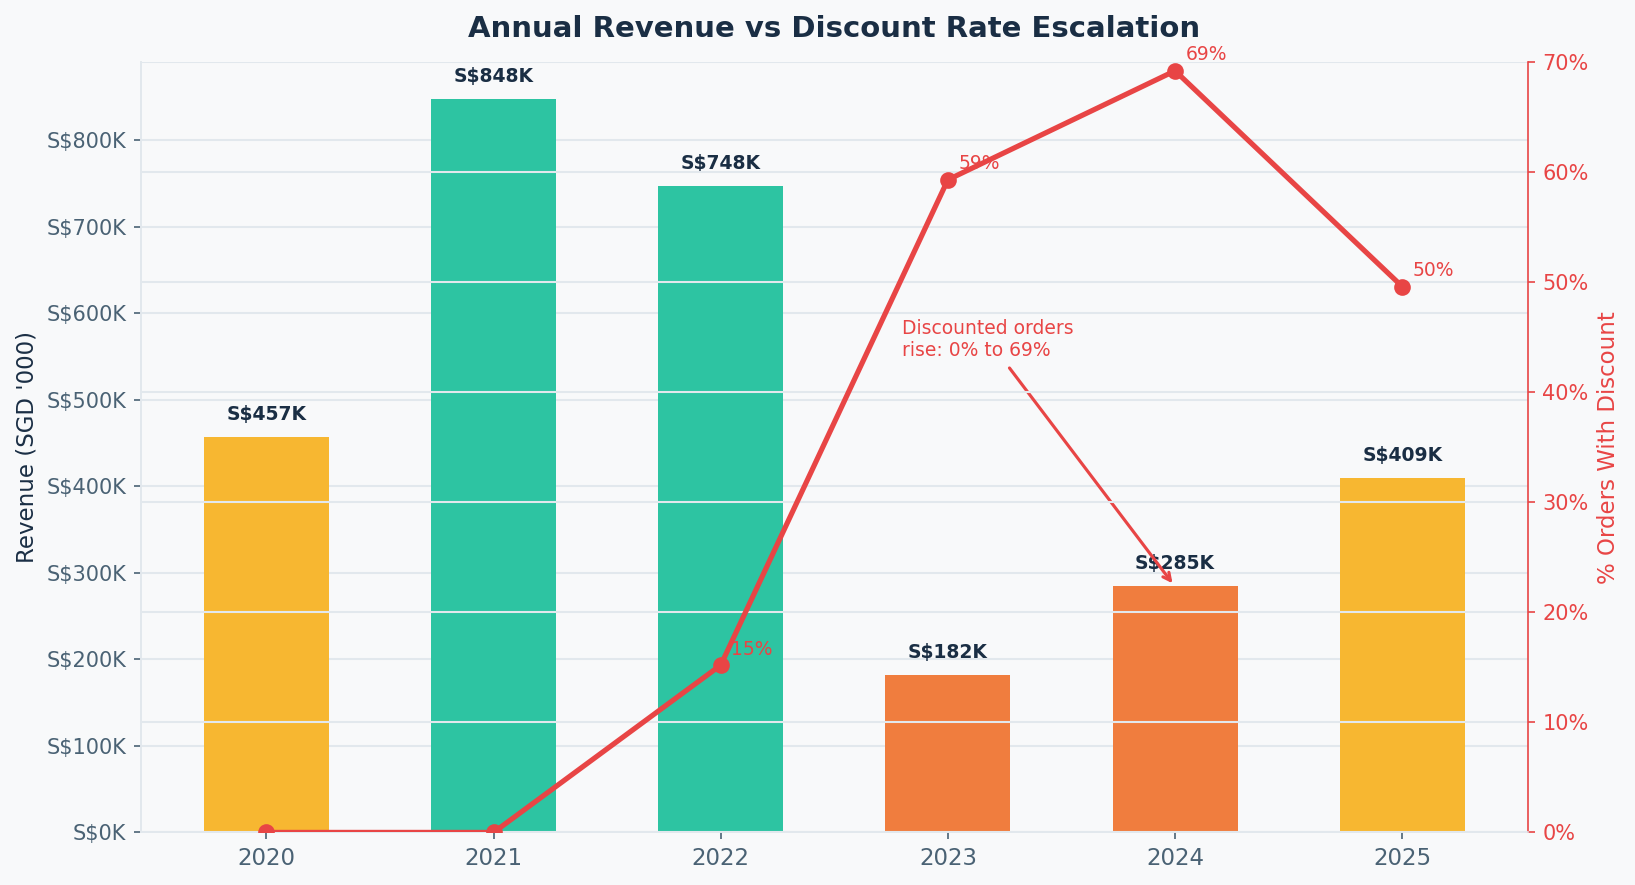

  Displayed inline: 01a_revenue_discount_trend


In [14]:
# ── Chart 1: Revenue + discount rate (dual axis) ─────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 6))
x = np.arange(len(years))
bars = ax1.bar(x, [r/1000 for r in revenue], color=[TEAL if r > 600000 else ORANGE if r < 400000 else GOLD for r in revenue], width=0.55, zorder=3)
ax1.set_xticks(x); ax1.set_xticklabels(years, fontsize=11)
ax1.set_ylabel("Revenue (SGD '000)", color=NAVY, fontsize=11)
ax1.set_title("Annual Revenue vs Discount Rate Escalation")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"S${v:.0f}K"))
for bar, r in zip(bars, revenue):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
             f"S${r/1000:.0f}K", ha="center", va="bottom", fontsize=9, color=NAVY, fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(x, disc_rate, color=RED, marker="o", linewidth=2.5, markersize=7, zorder=4, label="Discount rate")
ax2.set_ylabel("% Orders With Discount", color=RED, fontsize=11)
ax2.set_ylim(0, 70)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax2.spines["right"].set_visible(True); ax2.spines["right"].set_color(RED)
ax2.tick_params(axis="y", colors=RED)
for xi, dr in zip(x, disc_rate):
    if dr > 0:
        ax2.annotate(f"{dr:.0f}%", xy=(xi, dr), xytext=(5, 5), textcoords="offset points",
                     fontsize=9, color=RED)

ax1.annotate("Discounted orders\nrise: 0% to 69%", xy=(4, 284), xycoords="data",
             xytext=(2.8, 550), textcoords="data",
             arrowprops=dict(arrowstyle="->", color=RED, lw=1.5), color=RED, fontsize=9)

fig.tight_layout()
save(fig, "01a_revenue_discount_trend")



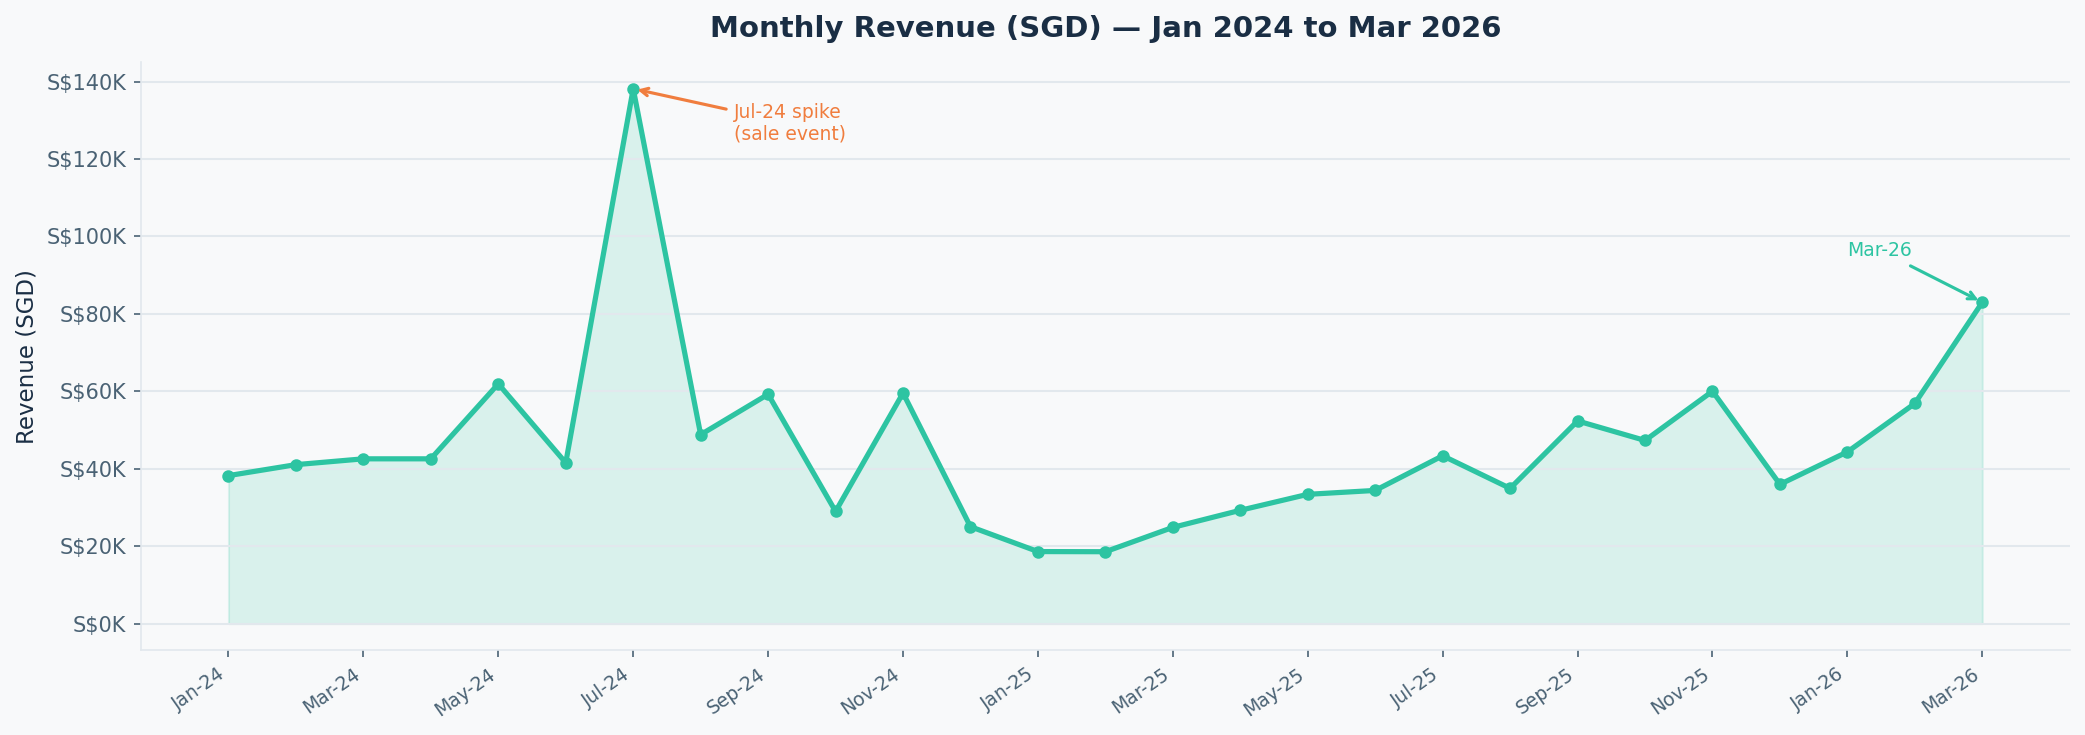

  Displayed inline: 01b_monthly_revenue_2024_2026


In [12]:
# ── Chart 2: Monthly revenue trend 2024-2026 ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(monthly_labels))
colors = [RED if v > 100000 else TEAL if v > 50000 else SLATE for v in monthly_rev]
ax.fill_between(x, monthly_rev, alpha=0.15, color=TEAL)
ax.plot(x, monthly_rev, color=TEAL, linewidth=2.5, marker="o", markersize=5, zorder=3)
ax.set_xticks(x[::2]); ax.set_xticklabels(monthly_labels[::2], rotation=35, ha="right", fontsize=9)
ax.set_title("Monthly Revenue (SGD) — Jan 2024 to Mar 2026")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"S${v/1000:.0f}K"))
ax.set_ylabel("Revenue (SGD)", fontsize=11)
ax.annotate("Jul-24 spike\n(sale event)", xy=(6, 138167), xytext=(7.5, 125000),
            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.5), color=ORANGE, fontsize=9)
ax.annotate("Mar-26", xy=(26, 83002), xytext=(24, 95000),
            arrowprops=dict(arrowstyle="->", color=TEAL, lw=1.5), color=TEAL, fontsize=9)
fig.tight_layout()
save(fig, "01b_monthly_revenue_2024_2026")



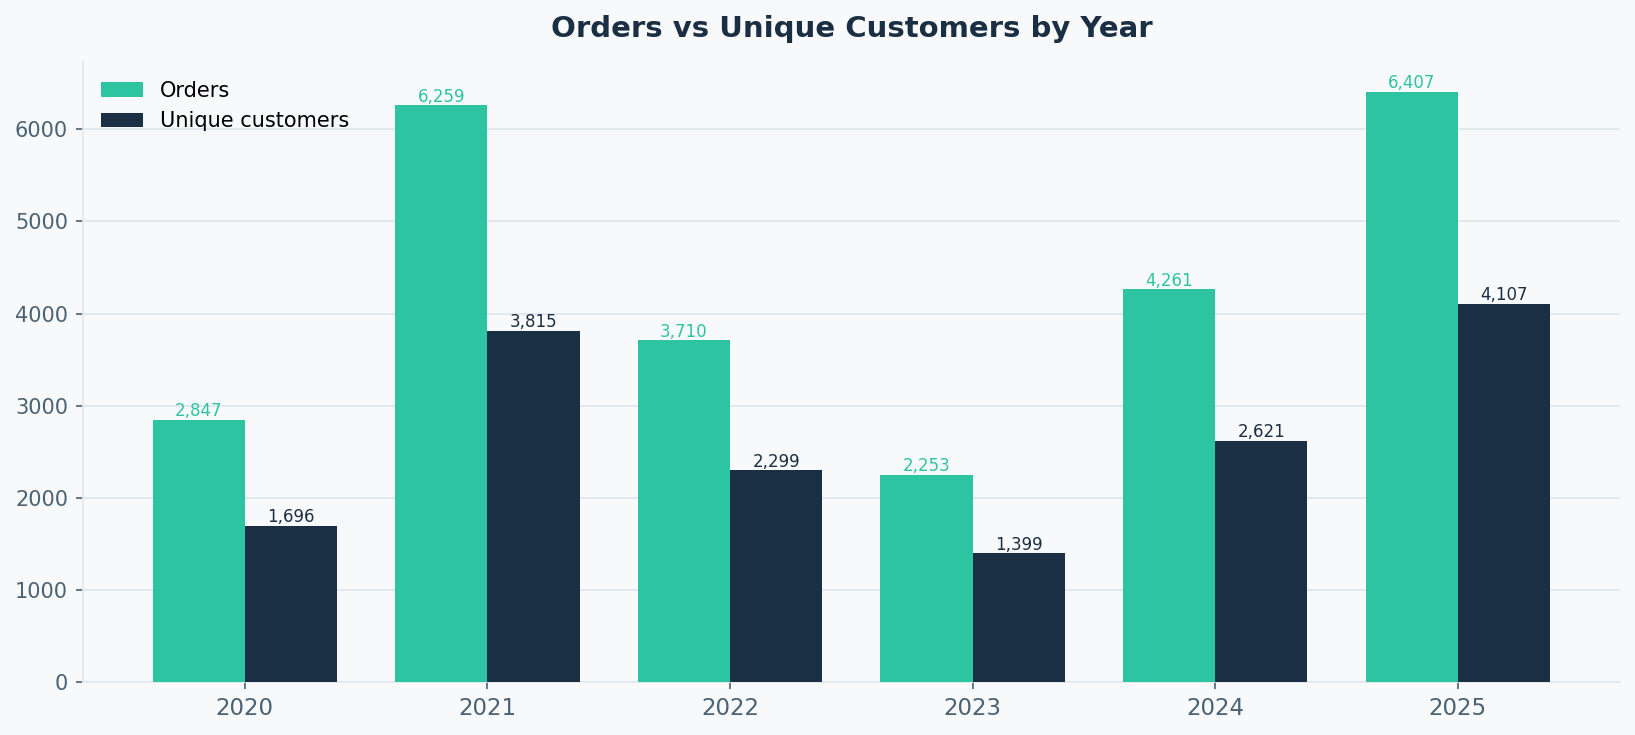

  Displayed inline: 01c_orders_customers_by_year
Done – 01_revenue_and_volume


In [13]:
# ── Chart 3: Orders and unique customers by year ─────────────────────────────
customers = [1696, 3815, 2299, 1399, 2621, 4107]  # all markets combined
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(years)); w = 0.38
b1 = ax.bar(x-w/2, orders, width=w, color=TEAL, label="Orders", zorder=3)
b2 = ax.bar(x+w/2, customers, width=w, color=NAVY, label="Unique customers", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(years, fontsize=11)
ax.set_title("Orders vs Unique Customers by Year")
ax.legend(loc="upper left")
for bar, v in zip(b1, orders):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+40, f"{v:,}", ha="center", fontsize=8, color=TEAL)
for bar, v in zip(b2, customers):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+40, f"{v:,}", ha="center", fontsize=8, color=NAVY)
fig.tight_layout()
save(fig, "01c_orders_customers_by_year")

print("Done – 01_revenue_and_volume")


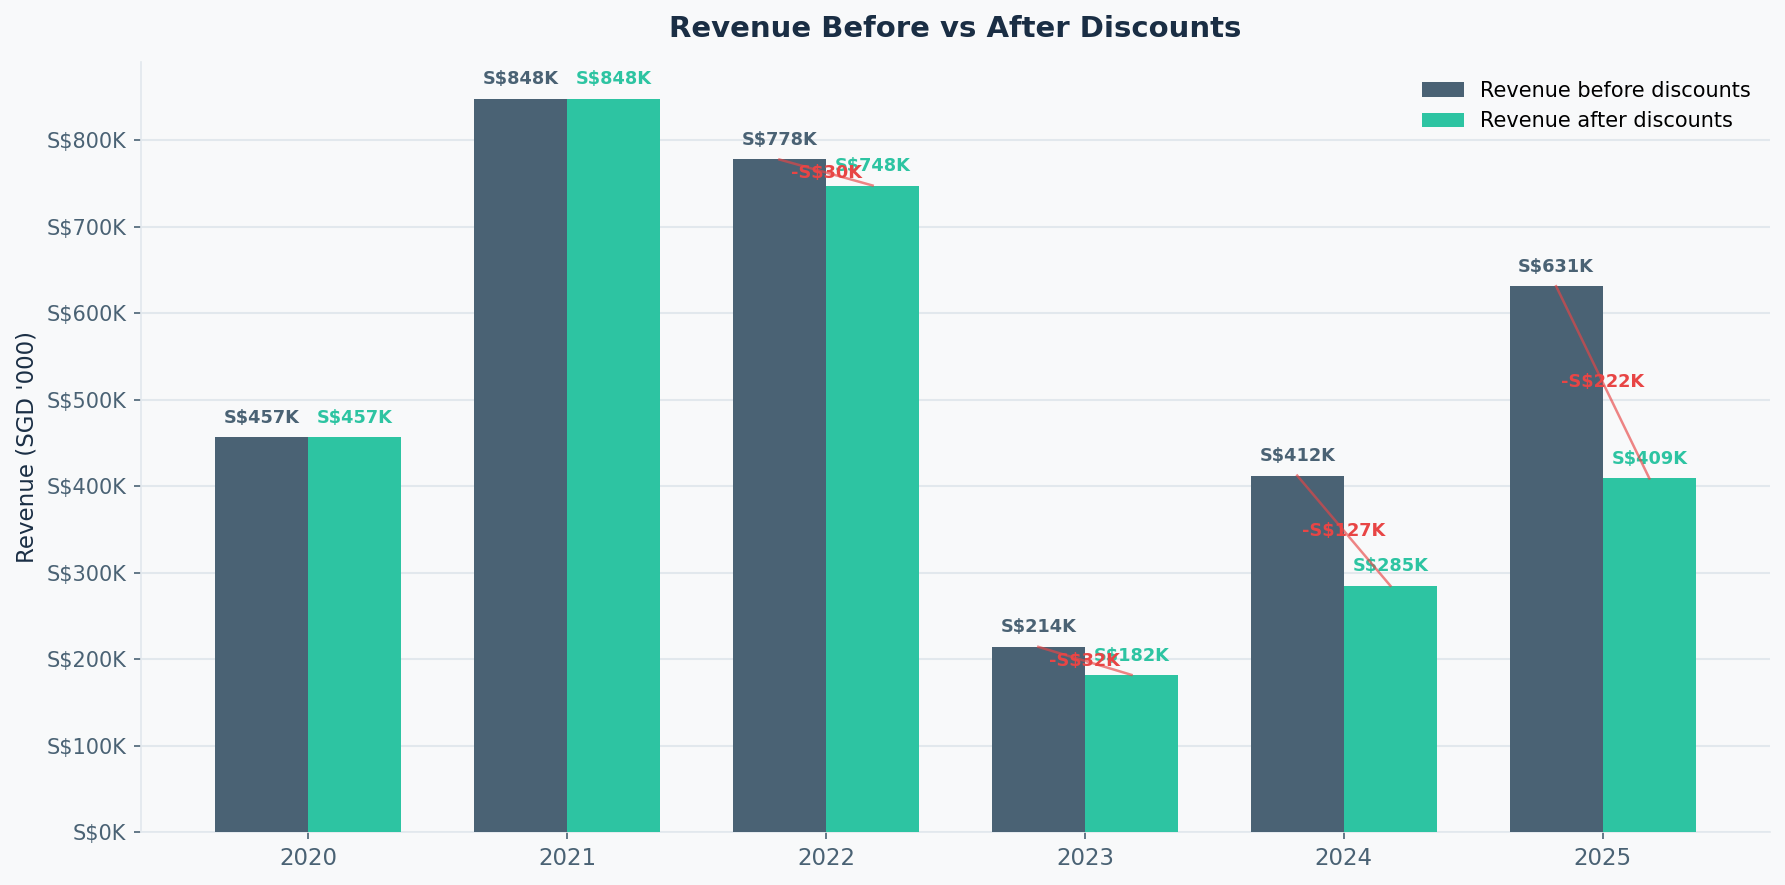

  Displayed inline: 01d_revenue_before_after_discounts


In [16]:
# ── Chart 1d: Gross revenue before discounts vs net revenue after discounts ───
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(years))
w = 0.36
b1 = ax.bar(x - w/2, [v/1000 for v in gross_revenue], width=w, color=SLATE,
            label="Revenue before discounts", zorder=3)
b2 = ax.bar(x + w/2, [v/1000 for v in revenue], width=w, color=TEAL,
            label="Revenue after discounts", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.set_ylabel("Revenue (SGD '000)", fontsize=11)
ax.set_title("Revenue Before vs After Discounts")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"S${v:.0f}K"))
ax.legend(loc="upper right")

for bar, v in zip(b1, gross_revenue):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+12,
            f"S${v/1000:.0f}K", ha="center", va="bottom",
            fontsize=8.5, color=SLATE, fontweight="bold")
for bar, v in zip(b2, revenue):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+12,
            f"S${v/1000:.0f}K", ha="center", va="bottom",
            fontsize=8.5, color=TEAL, fontweight="bold")

for xi, gross, net, disc in zip(x, gross_revenue, revenue, discounts):
    if disc > 0:
        ax.plot([xi - w/2, xi + w/2], [gross/1000, net/1000],
                color=RED, linewidth=1.2, alpha=0.65, zorder=4)
        ax.text(xi, (gross + net)/2000, f"-S${disc/1000:.0f}K",
                ha="center", va="center", fontsize=8.5,
                color=RED, fontweight="bold")

fig.tight_layout()
save(fig, "01d_revenue_before_after_discounts")

In [ ]:
# TODO: generate discount trend by source channel
fig, ax = plt.subplots(figsize=(12, 6))
